In [1]:
#Lab 1: Understanding the 0list E-commerce Dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path 
pd.set_option("display.max_column",None)
pd.set_option("display.max_rows",100)


In [3]:
DATA_DIR = Path("../data/raw")

In [4]:
DATA_DIR.exists()

True

In [5]:
for file in DATA_DIR.glob("*csv"):
    print(file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [6]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

tables={
    "customer" : customers,
    "geolocation" : geolocation,
    "oder_items" : order_items,
    "paymetns" : payments,
    "review" : reviews,
    "orders" : orders,
    "product" : products,
    "sellers" : sellers,
    "category_translation" : category_translation 
}

    


In [7]:
#task 6
for name,df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} column")

customer: 99441 rows, 5 column
geolocation: 1000163 rows, 5 column
oder_items: 112650 rows, 7 column
paymetns: 103886 rows, 5 column
review: 99224 rows, 7 column
orders: 99441 rows, 8 column
product: 32951 rows, 9 column
sellers: 3095 rows, 4 column
category_translation: 71 rows, 2 column


In [8]:
customers.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [9]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [11]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [12]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [13]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [14]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [15]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [16]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)
    print(df.info())


CUSTOMER
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

GEOLOCATION
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str  

In [17]:
def summarize_table(name, df):
    return {
    "table_name": name,
    "rows": df.shape[0],
    "columns": df.shape[1],
    "missing_values": df.isnull().sum().sum(),
    "duplicate_rows": df.duplicated().sum()
}
summary = pd.DataFrame([
summarize_table(name, df)
for name, df in tables.items()
])
summary

,table_name,rows,columns,missing_values,duplicate_rows
0,customer,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,oder_items,112650,7,0,0
3,paymetns,103886,5,0,0
4,review,99224,7,145903,0
5,orders,99441,8,4908,0
6,product,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [18]:
summary.to_csv("../reports/lab01_dataset_summary.csv", index=False)

In [19]:
def missing_value_summary(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    result = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})
    return result[result["missing_count"] > 0].sort_values(
by="missing_percent",
ascending=False
)
missing_value_summary(orders)

,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


In [20]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(f"Missing Values in {name}")
    print("=" * 80)
    display(missing_value_summary(df))


Missing Values in customer


,missing_count,missing_percent



Missing Values in geolocation


,missing_count,missing_percent



Missing Values in oder_items


...

,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070



Missing Values in sellers


,missing_count,missing_percent



Missing Values in category_translation


,missing_count,missing_percent


In [21]:
for name, df in tables.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name}: {duplicate_count} duplicate rows")

customer: 0 duplicate rows
geolocation: 261831 duplicate rows
oder_items: 0 duplicate rows
paymetns: 0 duplicate rows
review: 0 duplicate rows
orders: 0 duplicate rows
product: 0 duplicate rows
sellers: 0 duplicate rows
category_translation: 0 duplicate rows


In [22]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(f"Missing Values in {name}")
    print("=" * 80)
    display(missing_value_summary(df))


Missing Values in customer


,missing_count,missing_percent



Missing Values in geolocation


,missing_count,missing_percent



Missing Values in oder_items


...

,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070



Missing Values in sellers


,missing_count,missing_percent



Missing Values in category_translation


,missing_count,missing_percent


In [23]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [24]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

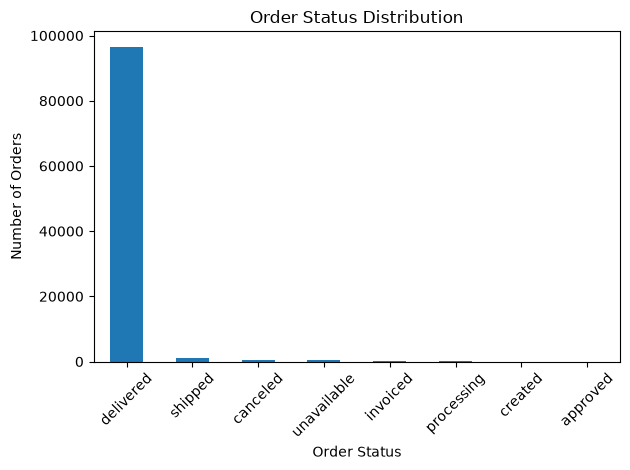

In [25]:
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

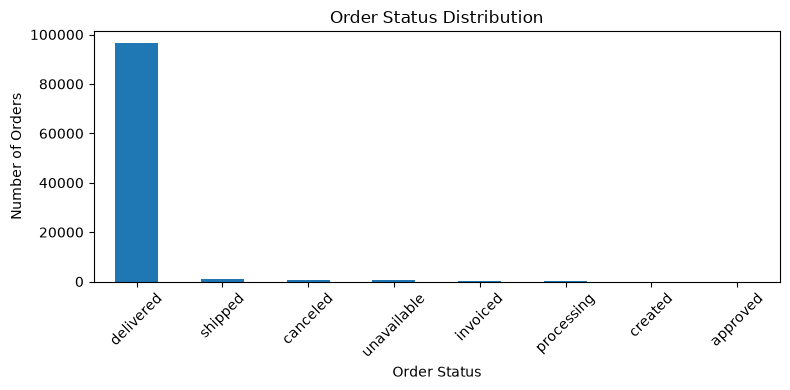

In [26]:
plt.figure(figsize=(8, 4))
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/lab01_order_status_distribution.png")
plt.show()

In [27]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [28]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

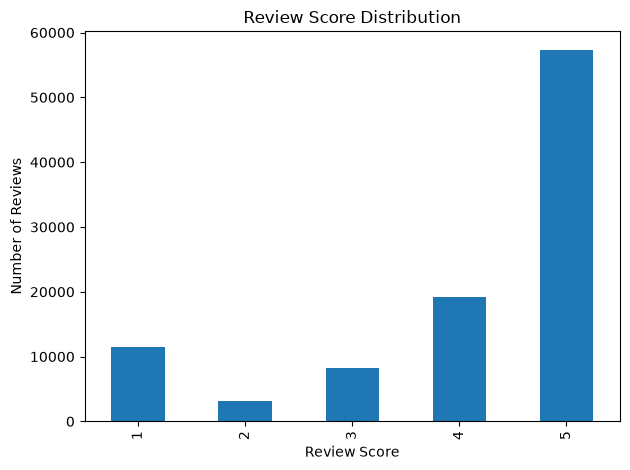

In [29]:
reviews["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [30]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [31]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

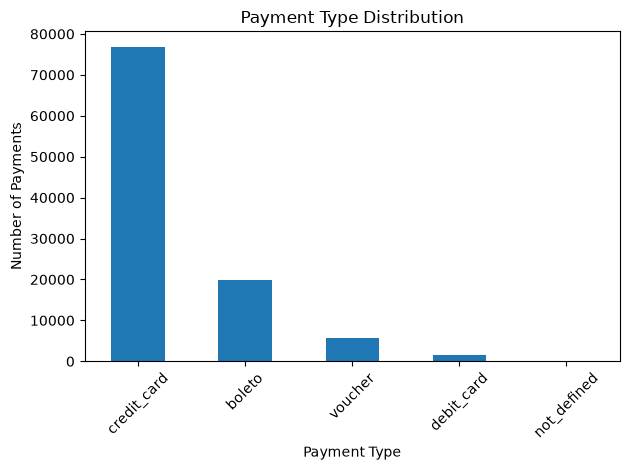

In [32]:
payments["payment_type"].value_counts().plot(kind="bar")
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [34]:
missing_value_summary(products)

,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


In [35]:
products["product_category_name"].nunique()

73

In [36]:
products["product_category_name"].value_counts().head(10)

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

In [37]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [38]:
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

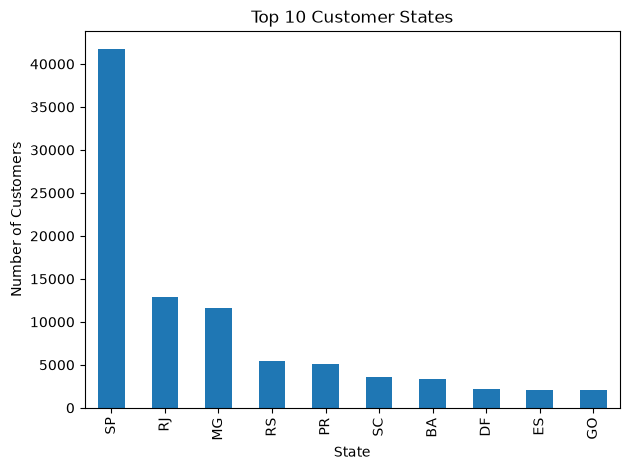

In [39]:
customers["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [40]:
customers["customer_unique_id"].nunique()

96096

In [41]:
orders["order_id"].nunique()

99441

In [42]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [43]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [44]:
reviews["review_score"].mean()

np.float64(4.08642062404257)

In [45]:
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

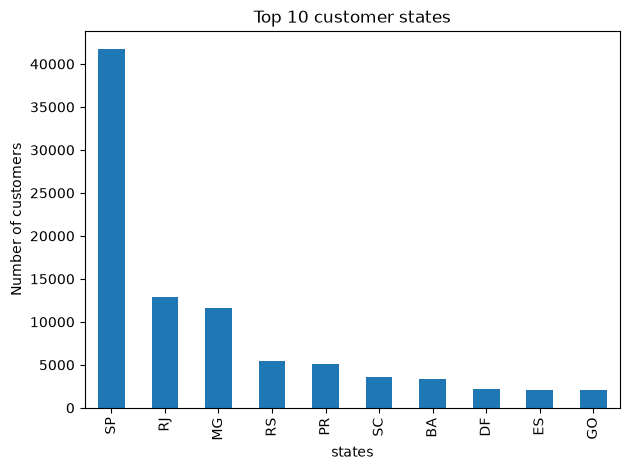

In [46]:
customers["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 customer states")
plt.xlabel("states")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

In [47]:
customers["customer_unique_id"].nunique()
orders["order_id"].nunique()
orders["order_status"].value_counts()
payments["payment_type"].value_counts()
reviews["review_score"].mean()
customers["customer_state"].value_counts().head(10)


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [48]:
# Task 18: Identify Potential Machine Learning Problems
import pandas as pd

ml_problems = pd.DataFrame({
    "ML Problem": [
        "Predict late delivery",
        "Predict review score",
        "Predict payment value",
        "Segment customers",
        "Recommend product categories",
        "Detect unusual orders",
        "Forecast monthly sales"
    ],
    "Type": [
        "Classification",
        "Regression/Classification",
        "Regression",
        "Clustering",
        "Recommendation",
        "Anomaly Detection",
        "Time Series Forecasting"
    ],
    "Possible Target": [
        "Late / Not Late",
        "review_score",
        "payment_value",
        "No explicit target",
        "product_category_name",
        "No explicit target",
        "Monthly revenue"
    ]
})

ml_problems

,ML Problem,Type,Possible Target
0,Predict late delivery,Classification,Late / Not Late
1,Predict review score,Regression/Classification,review_score
2,Predict payment value,Regression,payment_value
3,Segment customers,Clustering,No explicit target
4,Recommend product categories,Recommendation,product_category_name
5,Detect unusual orders,Anomaly Detection,No explicit target
6,Forecast monthly sales,Time Series Forecasting,Monthly revenue


In [49]:
# Task 19 : Create Initial Data Dictionary
import pandas as pd
data_dictionary = pd.DataFrame([
    # Customers Table
    ["customers", "customer_id", "String", "Unique customer identifier for each order", "abc123"],
    ["customers", "customer_unique_id", "String", "Unique customer identifier", "861eff4711a542e4b93843c6dd7febb0"],
    ["customers", "customer_zip_code_prefix", "Integer", "Customer ZIP code prefix", "14409"],
    ["customers", "customer_city", "String", "Customer city", "franca"],
    ["customers", "customer_state", "String", "Customer state", "SP"],

    # Orders Table
    ["orders", "order_id", "String", "Unique order identifier", "xyz789"],
    ["orders", "customer_id", "String", "Customer who placed the order", "abc123"],
    ["orders", "order_status", "String", "Current status of the order", "delivered"],
    ["orders", "order_purchase_timestamp", "Datetime", "Order purchase date and time", "2017-10-02 10:56:33"],
    ["orders", "order_approved_at", "Datetime", "Order approval date and time", "2017-10-02 11:07:15"],
    ["orders", "order_delivered_carrier_date", "Datetime", "Date when order was handed to the carrier", "2017-10-04 19:55:00"],
    ["orders", "order_delivered_customer_date", "Datetime", "Date when order was delivered to the customer", "2017-10-10 21:25:13"],
    ["orders", "order_estimated_delivery_date", "Datetime", "Estimated delivery date", "2017-10-18"],

    # Order Items Table
    ["order_items", "order_id", "String", "Order identifier", "xyz789"],
    ["order_items", "order_item_id", "Integer", "Item number within the order", "1"],
    ["order_items", "product_id", "String", "Purchased product identifier", "prod123"],
    ["order_items", "seller_id", "String", "Seller identifier", "seller567"],
    ["order_items", "shipping_limit_date", "Datetime", "Last date for shipping the product", "2017-09-19 09:45:35"],
    ["order_items", "price", "Float", "Price of the product", "58.90"],
    ["order_items", "freight_value", "Float", "Shipping cost", "13.29"]
], columns=[
    "Table",
    "Column",
    "Data Type",
    "Description",
    "Example Value"
])

data_dictionary

,Table,Column,Data Type,Description,Example Value
0,customers,customer_id,String,Unique customer identifier for each order,abc123
1,customers,customer_unique_id,String,Unique customer identifier,861eff4711a542e4b93843c6dd7febb0
2,customers,customer_zip_code_prefix,Integer,Customer ZIP code prefix,14409
3,customers,customer_city,String,Customer city,franca
4,customers,customer_state,String,Customer state,SP
5,orders,order_id,String,Unique order identifier,xyz789
6,orders,customer_id,String,Customer who placed the order,abc123
7,orders,order_status,String,Current status of the order,delivered
8,orders,order_purchase_timestamp,Datetime,Order purchase date and time,2017-10-02 10:56:33
9,orders,order_approved_at,Datetime,Order approval date and time,2017-10-02 11:07:15


In [50]:
git init

SyntaxError: invalid syntax (2830201818.py, line 1)

In [ ]:
1. Why is it important to understand the dataset before building a Machine Learning model?

Answer:Understanding the dataset helps identify its structure, features, data types, missing values, duplicates, and relationships between tables. This ensures proper data      preprocessing, feature selection, and model building, leading to more accurate and reliable results.

2. Which table appears to be the central table in the Olist dataset? Why?

Answer:The olist_orders_dataset is the central table because it connects with multiple other tables through order_id, such as:
  olist_order_items_dataset
  olist_order_payments_dataset
  olist_order_reviews_dataset
  olist_customers_dataset
  It contains the core information about every order.

3. What is the difference between customer_id and customer_unique_id?

Answer:customer_id: Identifies a customer for a single order. The same person may have different customer_id values across multiple orders
   customer_unique_id: Identifies the actual customer uniquely across all orders.4. Which columns appear to represent dates?

4. Which columns appear to represent dates?

Answer:The following columns represent dates/timestamps:
   order_purchase_timestamp
   order_approved_at
   order_delivered_carrier_date
   order_delivered_customer_date
   order_estimated_delivery_date
   review_creation_date
   review_answer_timestamp
   shipping_limit_date
  
5. Which columns appear to represent categorical variables?

Answer:Examples include:

   order_status
   customer_city
   customer_state
   seller_city
   seller_state
   product_category_name
   review_score
   payment_type

6. Which columns contain missing values?

Answer:Common columns with missing values include:

   order_approved_at
   order_delivered_carrier_date
   order_delivered_customer_date
   product_category_name
   product_name_lenght
   product_description_lenght
   product_photos_qty
   product_weight_g
   product_length_cm
   product_height_cm
   product_width_cm

7. Which tables can be joined using order_id?
 
Answer:The following tables can be joined using order_id:

   olist_orders_dataset
   olist_order_items_dataset
   olist_order_payments_dataset
   olist_order_reviews_dataset

8. Which tables can be joined using product_id?

Answer:The following tables can be joined using product_id:

   olist_order_items_dataset
   olist_products_dataset

9. What are three potential Machine Learning problems that can be created from this dataset?

Answer:Order Delivery Time Prediction (Regression):
   Predict how many days an order will take to be delivered based on order, seller, and customer information.
   Customer Review Score Prediction (Classification):
   Predict the review score (1–5 stars) that a customer is likely to give based on order details, delivery time, and product information.
   Order Cancellation Prediction (Classification):
   Predict whether an order is likely to be canceled using customer, payment, and order-related features.

10. What ethical concerns may arise when using customer data for ML?

Answer:Privacy: Customer personal information should be protected and handled securely.
   Data Security: Sensitive customer data must be stored and processed safely to prevent unauthorized access or data breaches.
   Bias and Fairness: Models should not unfairly discriminate against any group of customers due to biased data.
   Consent: Customer data should be used only with proper permission and for legitimate purposes.
   Anonymization: Personally identifiable information should be removed or anonymized before training Machine Learning models.